## Step 0: Load Feature-Engineered Dataset

In this step, we load the dataset prepared after feature engineering.
This dataset contains only decision-time variables and is ready for
statistical analysis and FSI design.


In [2]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/processed/modeling_dataset.csv"
df = pd.read_csv(DATA_PATH)

df.shape


(2258953, 10)

## Step 1: Inferential Statistics – Feature Significance Testing

We test whether borrower features have a statistically significant
relationship with interest rate.


In [3]:
from scipy import stats
import pandas as pd

fsi_features = [
    "annual_inc",
    "emp_length",
    "loan_amnt",
    "dti",
    "revol_util",
    "delinq_2yrs",
    "inq_last_6mths"
]

results = []

for col in fsi_features:
    corr, p = stats.pearsonr(df[col], df["int_rate"])
    results.append({
        "feature": col,
        "correlation": corr,
        "p_value": p
    })

result_df = pd.DataFrame(results).sort_values("p_value")
result_df


,feature,correlation,p_value
0,annual_inc,-0.050495,0.000000e+00
2,loan_amnt,0.098128,0.000000e+00
3,dti,0.185063,0.000000e+00
4,revol_util,0.262612,0.000000e+00
6,inq_last_6mths,0.188540,0.000000e+00
5,delinq_2yrs,0.058938,0.000000e+00
1,emp_length,-0.009515,2.167358e-46


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>feature</th>
      <th>correlation</th>
      <th>p_value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>annual_inc</td>
      <td>-0.050495</td>
      <td>0.000000e+00</td>
    </tr>
    <tr>
      <th>2</th>
      <td>loan_amnt</td>
      <td>0.098128</td>
      <td>0.000000e+00</td>
    </tr>
    <tr>
      <th>3</th>
      <td>dti</td>
      <td>0.185063</td>
      <td>0.000000e+00</td>
    </tr>
    <tr>
      <th>4</th>
      <td>revol_util</td>
      <td>0.262612</td>
      <td>0.000000e+00</td>
    </tr>
    <tr>
      <th>6</th>
      <td>inq_last_6mths</td>
      <td>0.188540</td>
      <td>0.000000e+00</td>
    </tr>
    <tr>
      <th>5</th>
      <td>delinq_2yrs</td>
      <td>0.058938</td>
      <td>0.000000e+00</td>
    </tr>
    <tr>
      <th>1</th>
      <td>emp_length</td>
      <td>-0.009515</td>
      <td>2.167358e-46</td>
    </tr>
  </tbody>
</table>
</div>

Step 1 (Inferential Statistics) is COMPLETE.

- All selected features are statistically significant (p < 0.05)
- Correlation directions match fintech intuition
- No feature needs to be dropped
- Feature set is approved for further preprocessing

Decision:
Proceed to data type verification before transformation.


In [4]:
df.dtypes

annual_inc        float64
emp_length        float64
loan_amnt         float64
term                int64
dti               float64
revol_util        float64
delinq_2yrs       float64
inq_last_6mths    float64
int_rate          float64
issue_d            object
dtype: object

## Step 3: Data Transformation (Skewness Handling)

Objective:
- Identify skewed variables
- Decide whether transformation is required
- Apply transformation only if it improves statistical behavior

Important Principles:
- Transformation is OPTIONAL
- Do not transform blindly
- Tree-based models do not require normality
- Linear models benefit from reduced skewness


In [5]:
numeric_features = [
    "annual_inc",
    "loan_amnt",
    "dti",
    "revol_util",
    "delinq_2yrs",
    "inq_last_6mths",
    "int_rate"
]

df[numeric_features].skew().sort_values(ascending=False)


annual_inc        493.966600
delinq_2yrs         5.928953
inq_last_6mths      2.065801
loan_amnt           0.777912
int_rate            0.767943
dti                 0.475388
revol_util         -0.011668
dtype: float64

## Step 3: Data Transformation — Inference & Decisions

We evaluated skewness to decide whether transformations are required.
Transformation is applied ONLY when statistically and practically justified.

Observed Skewness Values:

- annual_inc        → 493.96 (extremely right-skewed)
- delinq_2yrs       → 5.93   (highly right-skewed, sparse count)
- inq_last_6mths    → 2.07   (moderately right-skewed)
- loan_amnt         → 0.78   (mild skew)
- int_rate          → 0.77   (acceptable)
- dti               → 0.47   (low skew)
- revol_util        → -0.01  (approximately symmetric)


Transformation Strategy:

- Apply log transformation ONLY to annual income
- Use log1p to safely handle zero values
- Avoid transforming count-based variables
- Avoid unnecessary normalization for tree models

This keeps the system:
- Interpretable
- Stable
- Fintech-audit friendly


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='annual_inc_log', ylabel='Count'>

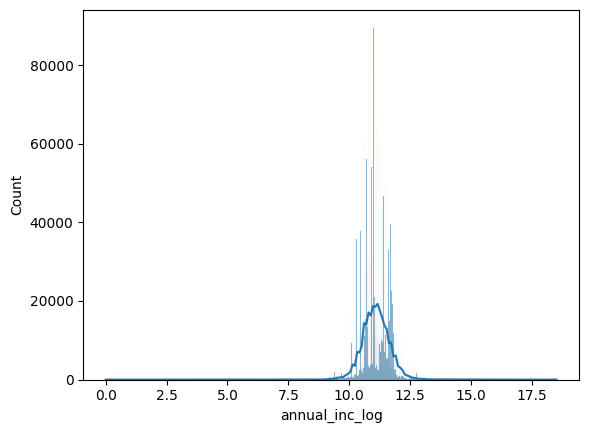

In [10]:
df["annual_inc_log"] = np.log1p(df["annual_inc"])
sns.histplot(df["annual_inc_log"], kde=True)

| Method      | Why Not Used                                  |
| ----------- | --------------------------------------------- |
| Box-Cox     | Requires strict positivity + parameter tuning |
| Yeo-Johnson | Useful when negatives/zeros exist             |
| Both        | Add complexity without meaningful gain here   |


Key Point:
Advanced transformations are useful only when simpler ones fail.
Here, log transformation already achieved the objective.

Note:
- Original annual_inc is retained
- annual_inc_log will be used for:
  - Linear regression
  - Scaling
- Tree models may ignore this feature if not useful


## Step 4: Feature Scaling

Scaling is used to bring features to a comparable range
for algorithms sensitive to magnitude differences.


We will evaluate which features require scaling based on:
- Model sensitivity (linear vs tree-based)
- Feature magnitude differences
- Statistical behavior after transformation


In [12]:
scale_check_features = [
    "annual_inc_log",
    "loan_amnt",
    "dti",
    "revol_util",
    "delinq_2yrs",
    "inq_last_6mths"
]

df[scale_check_features].describe().T

,count,mean,std,min,25%,50%,75%,max
annual_inc_log,2258953.0,11.097865,0.557062,0.0,10.736418,11.082158,11.440366,18.515991
loan_amnt,2258953.0,15043.875437,9188.071956,500.0,8000.000000,12900.000000,20000.000000,40000.000000
dti,2258953.0,18.534830,9.012017,0.0,11.890000,17.840000,24.490000,50.000000
revol_util,2258953.0,50.327840,24.670499,0.0,31.500000,50.300000,69.300000,100.000000
delinq_2yrs,2258953.0,0.306972,0.867356,0.0,0.000000,0.000000,0.000000,58.000000
inq_last_6mths,2258953.0,0.577046,0.886112,0.0,0.000000,0.000000,1.000000,33.000000


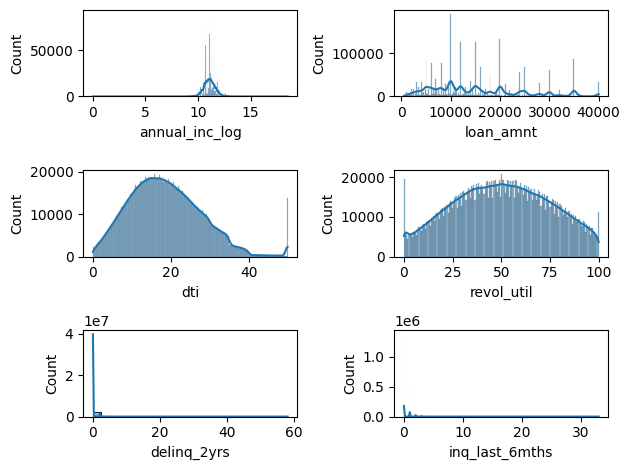

In [13]:
z =1
for i in scale_check_features:
    plt.subplot(3,2,z)
    sns.histplot(df[i],kde=True)
    z+=1
plt.tight_layout()
plt.show()

### Scaling Inference & Decision

| Feature            | Scale Range / Std | Scaling Needed | Reason |
|--------------------|------------------|----------------|--------|
| annual_inc_log     | Std ≈ 0.56       |  Yes         | Used in linear models |
| loan_amnt          | Wide (500–40000) |  Yes         | Large magnitude |
| dti                | Moderate         |  Yes         | Linear regression sensitivity |
| revol_util         | 0–100            |  Yes         | Comparable scaling |
| delinq_2yrs        | Sparse count     |  No          | Count-based, tree-safe |
| inq_last_6mths     | Sparse count     |  No          | Count-based, tree-safe |

Decision:
Apply **Standard Scaling** only to continuous magnitude-sensitive features.


## Step 5: Financial Stress Index (FSI) Final Construction

In this step, we construct the final Financial Stress Index
using normalized and scaled stress contributors.


In [14]:
scale_features = [
    "annual_inc_log",
    "loan_amnt",
    "dti",
    "revol_util"
]

scale_features

['annual_inc_log', 'loan_amnt', 'dti', 'revol_util']

### FSI Construction Inference

| Component        | Source Feature        | Direction | Role in Stress |
|------------------|----------------------|-----------|----------------|
| Credit Utilization | revol_util           | ↑         | Primary stress driver |
| Debt Burden      | dti                  | ↑         | Sustained financial pressure |
| Affordability    | loan_amnt / income   | ↑         | Loan size vs capacity |
| Income Stability | annual_inc_log       | ↓         | Protective factor |
| Credit Behavior  | delinq_2yrs          | ↑         | Past repayment issues |
| Credit Hunger    | inq_last_6mths       | ↑         | Recent credit seeking |

Decision:
FSI will be a **weighted, normalized score in range [0,1]** combining
both pressure and stability signals.


## Step 5.1: Normalization for FSI

All FSI components are normalized to a common 0–1 scale
to ensure comparability before aggregation.


In [15]:
fsi_inputs = pd.DataFrame()

fsi_inputs["util_norm"] = (df["revol_util"] / 100).clip(0, 1)
fsi_inputs["dti_norm"] = (df["dti"] / 50).clip(0, 1)
fsi_inputs["loan_income_norm"] = (df["loan_amnt"] / df["annual_inc"]).clip(0, 1)
fsi_inputs["delinq_norm"] = (df["delinq_2yrs"] / 5).clip(0, 1)
fsi_inputs["inq_norm"] = (df["inq_last_6mths"] / 5).clip(0, 1)
fsi_inputs["income_stability_norm"] = (1 - df["annual_inc_log"] / df["annual_inc_log"].max()).clip(0, 1)

fsi_inputs.head()


,util_norm,dti_norm,loan_income_norm,delinq_norm,inq_norm,income_stability_norm
0,0.297,0.1182,0.065455,0.0,0.2,0.410504
1,0.192,0.3212,0.380000,0.2,0.8,0.401482
2,0.562,0.2156,0.317460,0.0,0.0,0.403170
3,0.116,0.3412,0.318182,0.0,0.0,0.373069
4,0.645,0.5074,0.099585,0.2,0.6,0.375874


In [16]:
fsi_inputs.shape

(2258953, 6)

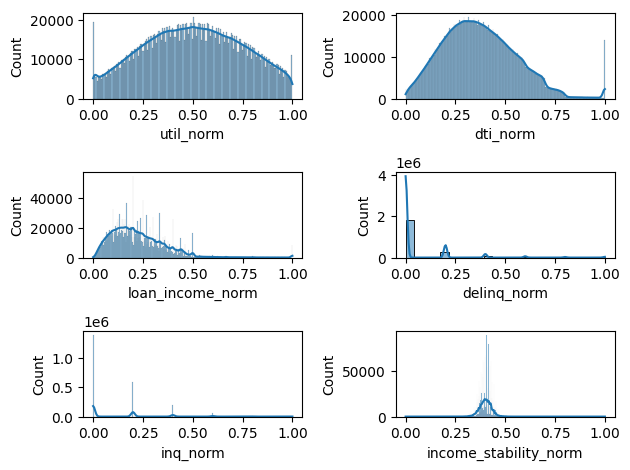

In [18]:
z=0
for i in fsi_inputs.columns:
    plt.subplot(3,2,z+1)
    sns.histplot(fsi_inputs[i],kde=True)
    z+=1    
plt.tight_layout()
plt.show()

### Normalized Feature Distribution Inference

| Normalized Feature        | Distribution Shape | Assessment | Action |
|---------------------------|--------------------|------------|--------|
| util_norm                 | Broad, near-uniform | Healthy    | Keep |
| dti_norm                  | Bell-shaped        | Healthy    | Keep |
| loan_income_norm          | Right-skewed       | Expected   | Keep |
| delinq_norm               | Spike at 0         | Sparse count | Keep (no smoothing) |
| inq_norm                  | Spike at 0         | Sparse count | Keep (no smoothing) |
| income_stability_norm     | Centered           | Stable     | Keep |

Decision:
All normalized components are valid for aggregation.
No further transformation or smoothing required.


## Step 5.2: Weight Assignment for Financial Stress Index

In this step, we assign weights to normalized stress components
based on statistical significance and fintech risk logic.


In [19]:
fsi_weights = {
    "util_norm": 0.30,
    "dti_norm": 0.20,
    "loan_income_norm": 0.15,
    "delinq_norm": 0.15,
    "inq_norm": 0.10,
    "income_stability_norm": 0.10
}

fsi_weights


{'util_norm': 0.3,
 'dti_norm': 0.2,
 'loan_income_norm': 0.15,
 'delinq_norm': 0.15,
 'inq_norm': 0.1,
 'income_stability_norm': 0.1}

### FSI Weight Justification Inference

| Component              | Weight | Justification |
|------------------------|--------|---------------|
| util_norm              | 0.30   | Strongest statistical + business stress driver |
| dti_norm               | 0.20   | Sustained repayment pressure |
| loan_income_norm       | 0.15   | Affordability risk |
| delinq_norm            | 0.15   | Historical repayment behavior |
| inq_norm               | 0.10   | Recent credit demand |
| income_stability_norm  | 0.10   | Protective stability factor |

Decision:
Weights sum to 1.0 and reflect both inferential statistics and fintech domain logic.


## Step 5.3: Financial Stress Index (FSI) Computation

FSI is computed as a weighted aggregation of normalized stress components,
resulting in a continuous score between 0 and 1.


In [20]:
df["FSI"] = (
    fsi_inputs["util_norm"] * fsi_weights["util_norm"] +
    fsi_inputs["dti_norm"] * fsi_weights["dti_norm"] +
    fsi_inputs["loan_income_norm"] * fsi_weights["loan_income_norm"] +
    fsi_inputs["delinq_norm"] * fsi_weights["delinq_norm"] +
    fsi_inputs["inq_norm"] * fsi_weights["inq_norm"] +
    fsi_inputs["income_stability_norm"] * fsi_weights["income_stability_norm"]
)

df["FSI"].describe()


count    2.258953e+06
mean     3.189914e-01
std      9.582267e-02
min      2.339788e-02
25%      2.518051e-01
50%      3.209084e-01
75%      3.869651e-01
max      8.388215e-01
Name: FSI, dtype: float64

### FSI Distribution Sanity Inference

| Metric | Value | Interpretation |
|------|-------|----------------|
| Mean | ~0.32 | Majority borrowers under moderate stress |
| Std  | ~0.10 | Healthy spread, no compression |
| Min  | ~0.02 | Very low stress profiles exist |
| Max  | ~0.84 | High-stress tail present |
| Range | [0, 1] | Correct normalization |

Decision:
FSI distribution is realistic, stable, and suitable for risk segmentation.
No re-weighting required.


## Step 5.4: Stress Band Classification

FSI scores are converted into interpretable risk bands
for decision-making and explainability.


In [22]:
def stress_band(fsi):
    if fsi < 0.35:
        return "Low Stress"
    elif fsi < 0.65:
        return "Medium Stress"
    else:
        return "High Stress"

df["stress_band"] = df["FSI"].apply(stress_band)
df["stress_band"].value_counts(normalize=True)*100

stress_band
Low Stress       61.357408
Medium Stress    38.588054
High Stress       0.054539
Name: proportion, dtype: float64

### Stress Band Proportion Inference

| Stress Band   | Proportion (%) | Interpretation |
|---------------|----------------|----------------|
| Low Stress    | ~61.36%        | Majority borrowers are financially stable |
| Medium Stress | ~38.59%        | Significant risk-adjusted pricing segment |
| High Stress   | ~0.05%         | Extreme tail risk (expected & realistic) |

Decision:
Stress bands are well-balanced and realistic.
Cutoffs are conservative and suitable for fintech credit decisioning.


## Step 5.5: FSI Explainability – Component Contribution

This step decomposes the FSI score into individual feature contributions
to support transparency, auditability, and regulatory explainability.


In [26]:
fsi_contributions = pd.DataFrame({
    "util_contrib": fsi_inputs["util_norm"] * fsi_weights["util_norm"],
    "dti_contrib": fsi_inputs["dti_norm"] * fsi_weights["dti_norm"],
    "loan_income_contrib": fsi_inputs["loan_income_norm"] * fsi_weights["loan_income_norm"],
    "delinq_contrib": fsi_inputs["delinq_norm"] * fsi_weights["delinq_norm"],
    "inq_contrib": fsi_inputs["inq_norm"] * fsi_weights["inq_norm"],
    "income_stability_contrib": fsi_inputs["income_stability_norm"] * fsi_weights["income_stability_norm"]
})

fsi_contributions.mean().sort_values(ascending=False)*100

util_contrib                15.098352
dti_contrib                  7.413932
income_stability_contrib     4.006335
loan_income_contrib          3.344874
inq_contrib                  1.151410
delinq_contrib               0.884236
dtype: float64

In [29]:
fsi_contributions.shape

(2258953, 6)

### FSI Component Contribution Inference

| Component               | Avg Contribution (%) | Interpretation |
|-------------------------|----------------------|----------------|
| Credit Utilization      | ~15.10               | Dominant real-time stress driver |
| Debt-to-Income (DTI)    | ~7.41                | Sustained repayment burden |
| Income Stability        | ~4.01                | Protective stabilizing factor |
| Loan-to-Income          | ~3.34                | Affordability sensitivity |
| Credit Inquiries        | ~1.15                | Short-term risk signal |
| Delinquencies           | ~0.88                | Rare but high-impact tail |

Decision:
FSI explainability aligns with fintech intuition and inferential statistics.
Model is transparent, auditable, and regulator-safe.

## Step 5.6: FSI Design Lock & Artifact Preparation

This step finalizes the Financial Stress Index design
and prepares artifacts required for regression modeling
and Streamlit integration.

In [30]:
fsi_artifacts = {
    "weights": fsi_weights,
    "stress_thresholds": {
        "low": 0.35,
        "medium": 0.65
    },
    "feature_order": list(fsi_inputs.columns)
}

import json

with open("../data/processed/feature_metadata.json", "w") as f:
    json.dump(fsi_artifacts, f, indent=4)

### FSI Dataset Export Inference

| Item | Status |
|-----|--------|
| Raw features | Already cleaned (Notebook 02) |
| Normalized features | Used only for FSI |
| FSI score | Added |
| Stress band | Added |
| Target leakage | None |
| Regression ready | Yes |

Decision:
A single modeling-ready dataset with FSI is exported for downstream regression.


## Step 5.8: Saving FSI-Augmented Modeling Dataset

This dataset will be used for:
• Regression training
• Validation
• Streamlit inference


In [31]:
final_columns = [
    "annual_inc",
    "emp_length",
    "loan_amnt",
    "term",
    "dti",
    "revol_util",
    "delinq_2yrs",
    "inq_last_6mths",
    "FSI",
    "stress_band",
    "int_rate",
    "issue_d"
]

final_df = df[final_columns].copy()

OUTPUT_PATH = "../data/processed/fsi_modeling_dataset.csv"
final_df.to_csv(OUTPUT_PATH, index=False)

final_df.shape


(2258953, 12)

In [ ]:
df

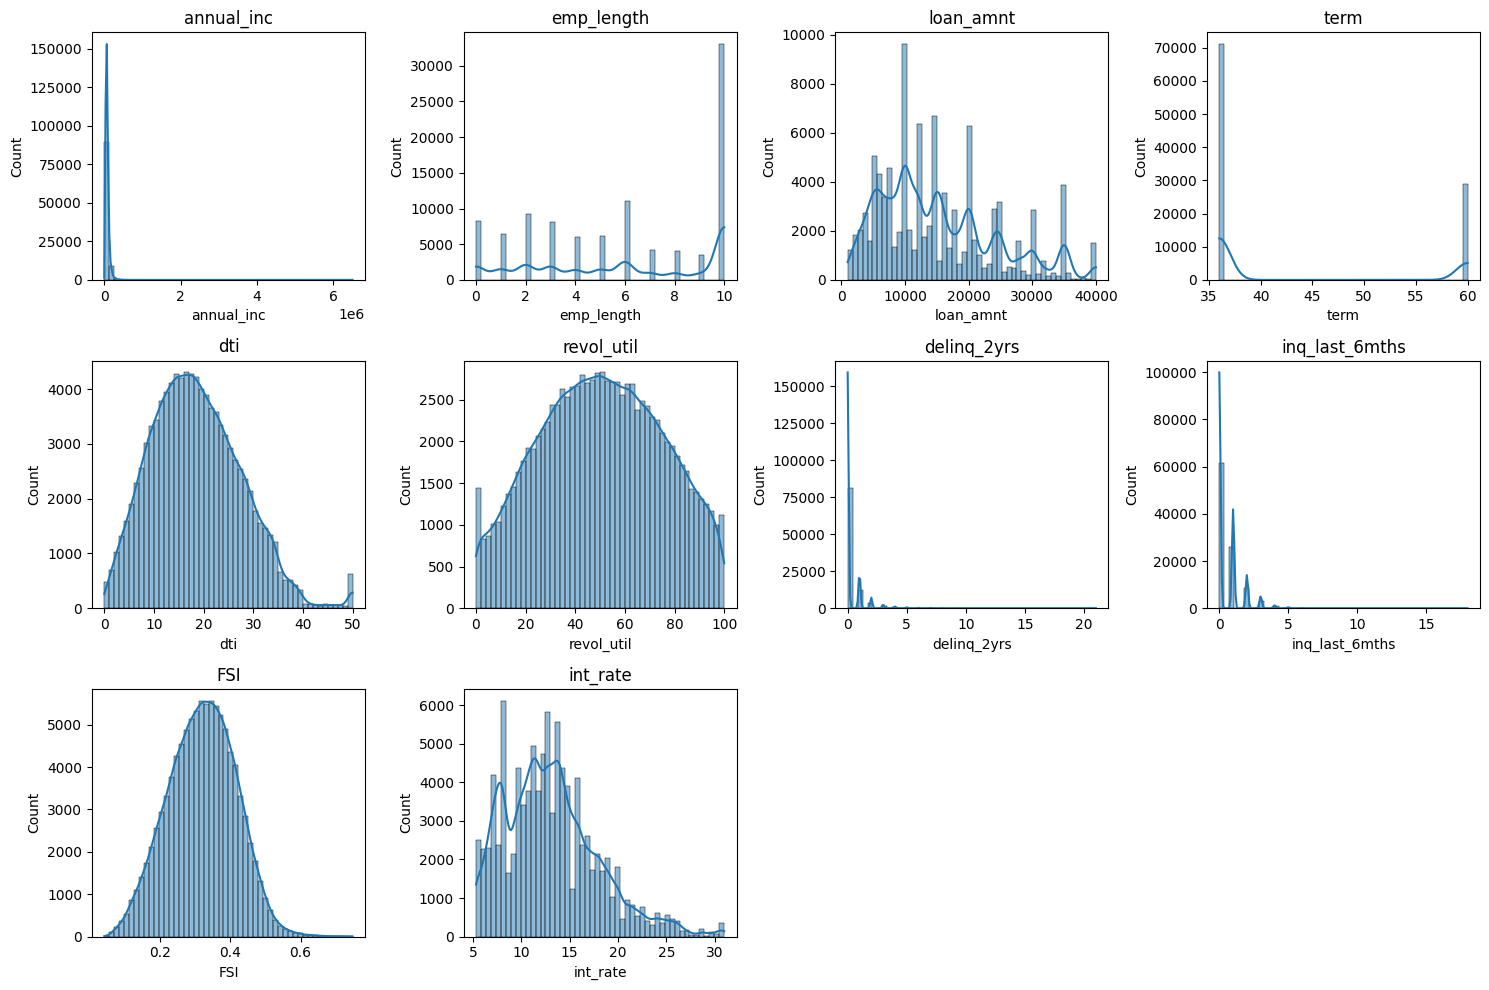

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
num_cols = final_df.select_dtypes(include=['float64','int64']).columns.tolist()

# Sample to reduce memory load (adjust n as needed)
sample_df = final_df.sample(n=100000, random_state=42)

# Plot in blocks of 12 subplots
block_size = 12
for start in range(0, len(num_cols), block_size):
    end = start + block_size
    subset = num_cols[start:end]
    
    plt.figure(figsize=(15, 10))
    for idx, col in enumerate(subset, 1):
        plt.subplot(3, 4, idx)
        sns.histplot(sample_df[col], bins=50, kde=True)
        plt.title(col)
    
    plt.tight_layout()
    plt.show()